In [54]:
# Core
import os, io, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context="notebook", style="whitegrid")

# ML
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [55]:
#load the CSV 
df = pd.read_csv("California_Fire_Incidents.csv" , low_memory=False)

print("Shape:", df.shape)
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue()[:1200])  # first ~1200 chars of df.info()

display(df.head(10))  # quick peek

Shape: (1636, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636 entries, 0 to 1635
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AcresBurned           1633 non-null   float64
 1   Active                1636 non-null   bool   
 2   AdminUnit             1636 non-null   object 
 3   AirTankers            28 non-null     float64
 4   ArchiveYear           1636 non-null   int64  
 5   CalFireIncident       1636 non-null   bool   
 6   CanonicalUrl          1636 non-null   object 
 7   ConditionStatement    284 non-null    object 
 8   ControlStatement      105 non-null    object 
 9   Counties              1636 non-null   object 
 10  CountyIds             1636 non-null   object 
 11  CrewsInvolved         171 non-null    float64
 12  Dozers                123 non-null    float64
 13  Engines               191 non-null    float64
 14  Extinguished          1577 non-null   object 
 15  Fat

,AcresBurned,Active,AdminUnit,AirTankers,ArchiveYear,CalFireIncident,CanonicalUrl,ConditionStatement,ControlStatement,Counties,...,SearchKeywords,Started,Status,StructuresDamaged,StructuresDestroyed,StructuresEvacuated,StructuresThreatened,UniqueId,Updated,WaterTenders
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,NaN,2013,True,/incidents/2013/8/17/rim-fire/,NaN,NaN,Tuolumne,...,"Rim Fire, Stanislaus National Forest, Yosemite...",2013-08-17T15:25:00Z,Finalized,NaN,NaN,NaN,NaN,5fb18d4d-213f-4d83-a179-daaf11939e78,2013-09-06T18:30:00Z,NaN
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,NaN,2013,True,/incidents/2013/5/30/powerhouse-fire/,NaN,NaN,Los Angeles,...,"Powerhouse Fire, May 2013, June 2013, Angeles ...",2013-05-30T15:28:00Z,Finalized,NaN,NaN,NaN,NaN,bf37805e-1cc2-4208-9972-753e47874c87,2013-06-08T18:30:00Z,NaN
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,NaN,2013,True,/incidents/2013/7/15/mountain-fire/,NaN,NaN,Riverside,...,"Mountain Fire, July 2013, Highway 243, Highway...",2013-07-15T13:43:00Z,Finalized,NaN,NaN,NaN,NaN,a3149fec-4d48-427c-8b2c-59e8b79d59db,2013-07-30T18:00:00Z,NaN
3,27440.0,False,Tahoe National Forest,NaN,2013,False,/incidents/2013/8/10/american-fire/,NaN,NaN,Placer,...,"American Fire, August 2013, Deadwood Ridge, Fo...",2013-08-10T16:30:00Z,Finalized,NaN,NaN,NaN,NaN,8213f5c7-34fa-403b-a4bc-da2ace6e6625,2013-08-30T08:00:00Z,NaN
4,24251.0,False,Ventura County Fire/CAL FIRE,NaN,2013,True,/incidents/2013/5/2/springs-fire/,Acreage has been reduced based upon more accur...,NaN,Ventura,...,"Springs Fire, May 2013, Highway 101, Camarillo...",2013-05-02T07:01:00Z,Finalized,6.0,10.0,NaN,NaN,46731fb8-3350-4920-bdf7-910ac0eb715c,2013-05-11T06:30:00Z,11.0
5,22992.0,False,Sierra National Forest,NaN,2013,False,/incidents/2013/7/22/aspen-fire/,NaN,NaN,Fresno,...,"217 Aspen Fire, July 2013, Big Creek, Fresno ...",2013-07-22T22:15:00Z,Finalized,NaN,NaN,NaN,NaN,bee8c339-4f26-4b78-a5b4-a8a0ebdb8786,2013-09-24T20:15:00Z,NaN
6,20292.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,NaN,2013,True,/incidents/2013/8/7/silver-fire/,Firefighters closed the containment lines toda...,Hwy 243 remains closed between Twin Pines Road...,Riverside,...,"Silver Fire, August 2013, Popet Flats Road, Hi...",2013-08-07T14:05:00Z,Finalized,8.0,40.0,NaN,NaN,c400203b-a7fd-4bd8-803a-f3c74bc32a2b,2013-08-12T18:00:00Z,20.0
7,14754.0,False,Klamath National Forest,NaN,2013,False,/incidents/2013/7/31/salmon-river-complex/,NaN,NaN,Siskiyou,...,"210 Salmon River Complex, August 2013, July 20...",2013-07-31T22:00:00Z,Finalized,NaN,NaN,NaN,NaN,ba76c009-09c9-497c-b923-1ac8cf05c20d,2013-08-31T06:45:00Z,NaN
8,12503.0,False,Six Rivers National Forest,NaN,2013,False,/incidents/2013/8/10/corral-complex/,NaN,NaN,Humboldt,...,"Corral Complex, August 2013, Tish Tang Ridge, ...",2013-08-10T11:40:00Z,Finalized,NaN,NaN,NaN,NaN,f3dcbca8-f8ed-46d0-8f6e-9c7fc2fb03e6,2013-08-12T12:00:00Z,NaN
9,11429.0,False,CAL FIRE Tehama-Glenn Unit,NaN,2013,True,/incidents/2013/8/23/deer-fire/,Fire suppression repair will continue througho...,NaN,Tehama,...,"Deer Fire, August 2013, Tehama County, Deer Cr...",2013-08-23T14:15:00Z,Finalized,NaN,NaN,NaN,NaN,956dbcf6-db40-4b61-b235-4ede14738f1e,2013-08-29T16:45:00Z,8.0


,column,missing_%
0,StructuresEvacuated,100.000000
1,FuelType,99.266504
2,Fatalities,98.716381
3,AirTankers,98.288509
4,StructuresThreatened,98.166259
5,StructuresDamaged,95.904645
6,Helicopters,94.865526
7,ControlStatement,93.581907
8,Injuries,92.665037
9,Dozers,92.481663


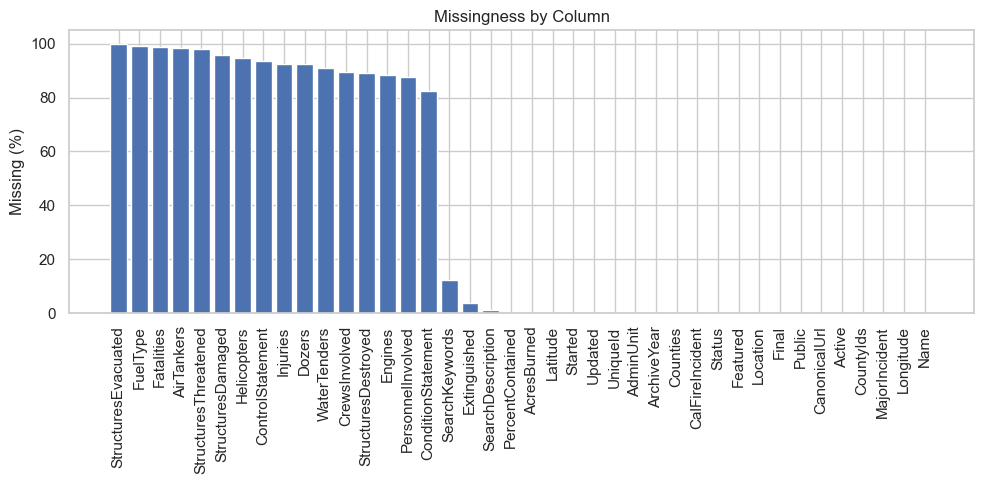

In [56]:
#Missingness Overview
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_df = missing_pct.to_frame("missing_%").reset_index().rename(columns={"index":"column"})
display(missing_df.head(20))

plt.figure(figsize=(10,5))
plt.bar(missing_df["column"], missing_df["missing_%"])
plt.xticks(rotation=90)
plt.ylabel("Missing (%)")
plt.title("Missingness by Column")
plt.tight_layout()
plt.show()


In [57]:
# Target Creation and Basic Cleaning
work = df.copy()

# Ensure numeric
work["AcresBurned"] = pd.to_numeric(work["AcresBurned"], errors="coerce")

# Drop rows without target, then create binary target
work = work.dropna(subset=["AcresBurned"]).copy()
work["LargeFire"] = (work["AcresBurned"] >= 1000).astype(int)

print("Rows used:", len(work))
print("Positive rate (LargeFire=1):", work["LargeFire"].mean().round(4))

# Parse dates when available
for c in ["Started", "Updated"]:
    if c in work.columns:
        work[c] = pd.to_datetime(work[c], errors="coerce")

print("Date coverage:", work["Started"].min(), "→", work["Started"].max())


Rows used: 1633
Positive rate (LargeFire=1): 0.1868
Date coverage: 1969-12-31 16:00:00+00:00 → 2019-11-25 19:59:12+00:00


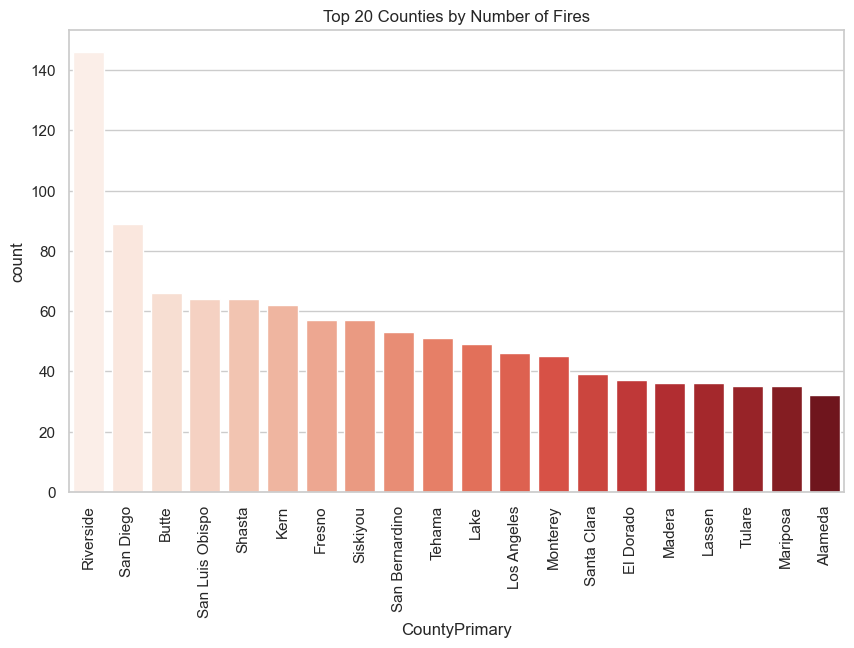

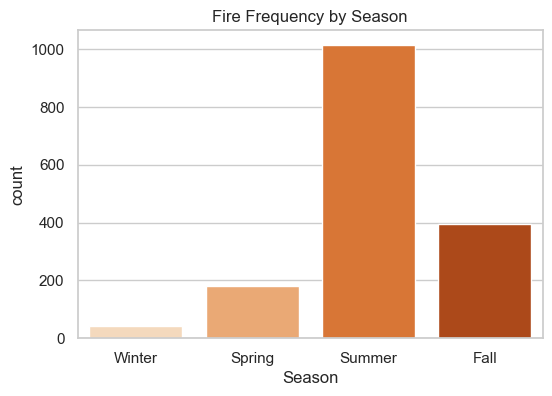

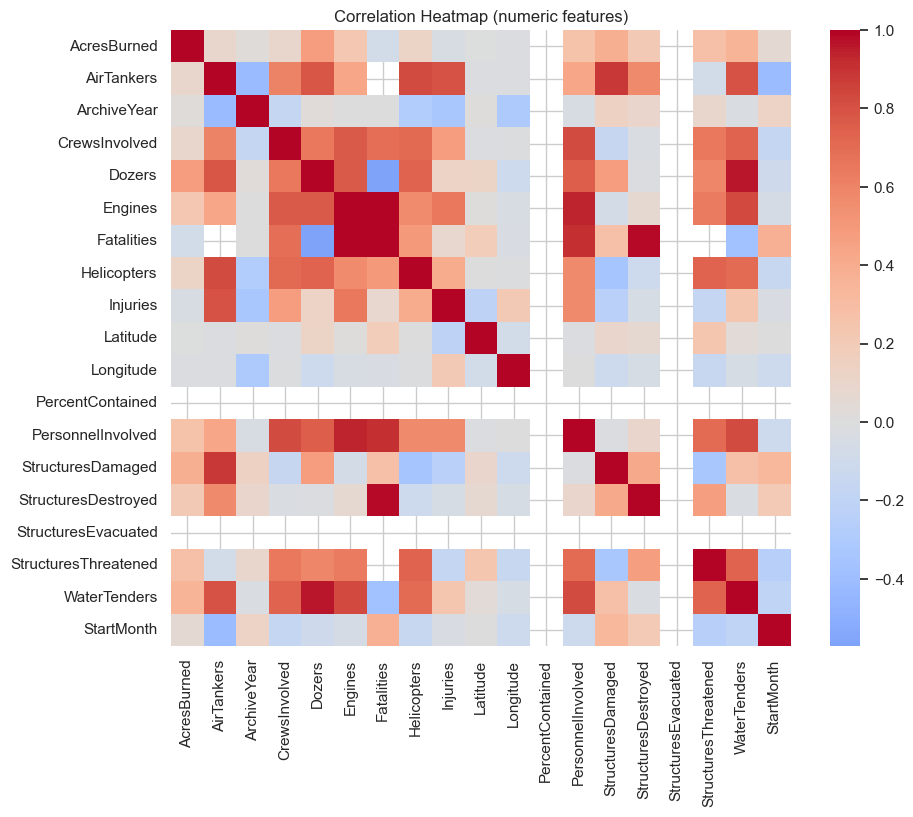

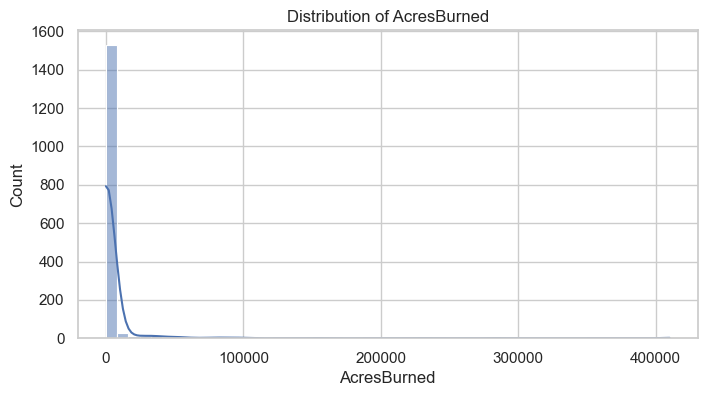

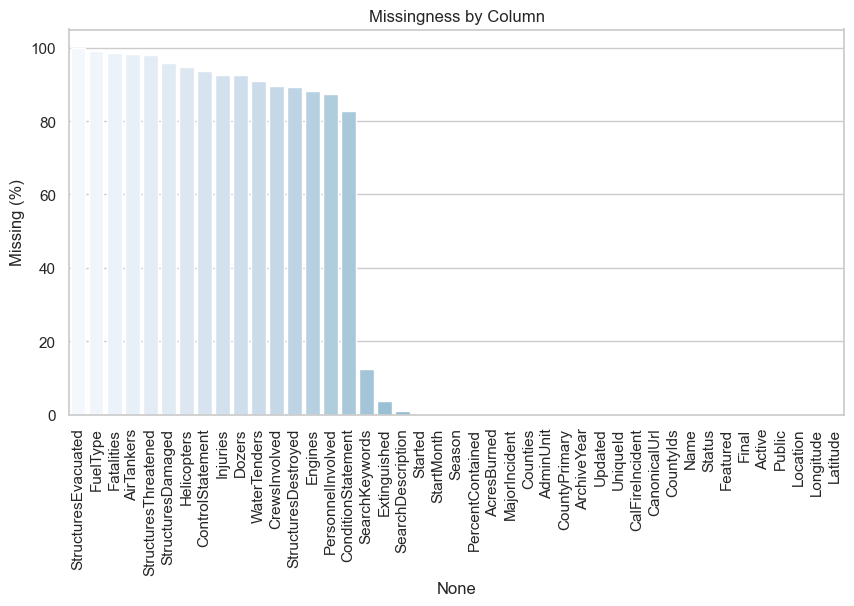

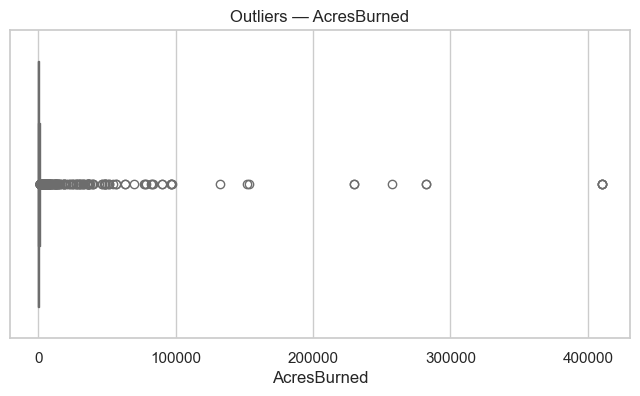

In [58]:
#EDA
# 1. Fire frequency by region (CountyPrimary) and season
if "Counties" in df.columns:
    df["CountyPrimary"] = df["Counties"].astype(str).str.split(",").str[0].str.strip()

if "Started" in df.columns:
    df["Started"] = pd.to_datetime(df["Started"], errors="coerce")
    df["StartMonth"] = df["Started"].dt.month
    df["Season"] = df["StartMonth"].map({12:"Winter",1:"Winter",2:"Winter",
                                         3:"Spring",4:"Spring",5:"Spring",
                                         6:"Summer",7:"Summer",8:"Summer",
                                         9:"Fall",10:"Fall",11:"Fall"})

plt.figure(figsize=(10,6))
sns.countplot(data=df, x="CountyPrimary", order=df["CountyPrimary"].value_counts().index[:20], palette="Reds")
plt.xticks(rotation=90); plt.title("Top 20 Counties by Number of Fires")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Season", order=["Winter","Spring","Summer","Fall"], palette="Oranges")
plt.title("Fire Frequency by Season")
plt.show()

# 2. Correlations
num_cols = df.select_dtypes(include="number").columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.show()

# 3. Distribution of AcresBurned
plt.figure(figsize=(8,4))
sns.histplot(df["AcresBurned"].dropna(), bins=50, kde=True)
plt.title("Distribution of AcresBurned")
plt.show()

# 4. Missingness
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10,5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, palette="Blues")
plt.xticks(rotation=90)
plt.ylabel("Missing (%)")
plt.title("Missingness by Column")
plt.show()

# 5. Outliers (boxplot)
plt.figure(figsize=(8,4))
sns.boxplot(x=df["AcresBurned"].dropna(), color="salmon")
plt.title("Outliers — AcresBurned")
plt.show()


In [59]:
#Feature Engineering
fe = work.copy()
# County primary (first county listed)
if "Counties" in fe.columns:
    fe["CountyPrimary"] = fe["Counties"].astype(str).str.split(",").str[0].str.strip()
else:
    fe["CountyPrimary"] = np.nan

# ArchiveYear numeric
if "ArchiveYear" in fe.columns:
    fe["ArchiveYear"] = pd.to_numeric(fe["ArchiveYear"], errors="coerce")

# Date-derived features (if 'Started' exists)
if "Started" in fe.columns:
    fe["StartYear"]     = fe["Started"].dt.year
    fe["StartMonth"]    = fe["Started"].dt.month
    fe["StartDOY"]      = fe["Started"].dt.dayofyear
    fe["StartWeekday"]  = fe["Started"].dt.weekday

    def month_to_season(m):
        if pd.isna(m): return np.nan
        m = int(m)
        return 0 if m in [12,1,2] else (1 if m in [3,4,5] else (2 if m in [6,7,8] else 3))
    fe["StartSeason"] = fe["StartMonth"].apply(month_to_season)

# Duration between Updated and Started (can be post-hoc / leakage!)
if {"Started","Updated"}.issubset(fe.columns):
    fe["DurationDays"] = (fe["Updated"] - fe["Started"]).dt.total_seconds() / (24*3600)

# Operational/resource columns → numeric
for c in ["Engines","Dozers","AirTankers","Helicopters","CrewsInvolved",
          "PersonnelInvolved","WaterTenders","PercentContained"]:
    if c in fe.columns:
        fe[c] = pd.to_numeric(fe[c], errors="coerce")

# Binary flags (if appear as strings)
for c in ["Active","Public","CalFireIncident"]:
    if c in fe.columns:
        fe[c] = fe[c].astype(str).str.lower().map({"true":1,"false":0,"1":1,"0":0}).fillna(0).astype(int)

# Choose candidate feature sets
candidate_numeric = [c for c in [
    "ArchiveYear","StartYear","StartMonth","StartDOY","StartWeekday","StartSeason",
    "DurationDays","Engines","Dozers","AirTankers","Helicopters",
    "CrewsInvolved","PersonnelInvolved","WaterTenders","PercentContained"
] if c in fe.columns]

candidate_categorical = [c for c in ["CountyPrimary","Status"] if c in fe.columns]

print("Numeric features:", candidate_numeric)
print("Categorical features:", candidate_categorical)

display(fe[candidate_numeric + candidate_categorical + ["LargeFire"]].head(10))


Numeric features: ['ArchiveYear', 'StartYear', 'StartMonth', 'StartDOY', 'StartWeekday', 'StartSeason', 'DurationDays', 'Engines', 'Dozers', 'AirTankers', 'Helicopters', 'CrewsInvolved', 'PersonnelInvolved', 'WaterTenders', 'PercentContained']
Categorical features: ['CountyPrimary', 'Status']


,ArchiveYear,StartYear,StartMonth,StartDOY,StartWeekday,StartSeason,DurationDays,Engines,Dozers,AirTankers,Helicopters,CrewsInvolved,PersonnelInvolved,WaterTenders,PercentContained,CountyPrimary,Status,LargeFire
0,2013,2013.0,8.0,229.0,5.0,2.0,20.128472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Tuolumne,Finalized,1
1,2013,2013.0,5.0,150.0,3.0,1.0,9.126389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Los Angeles,Finalized,1
2,2013,2013.0,7.0,196.0,0.0,2.0,15.178472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Riverside,Finalized,1
3,2013,2013.0,8.0,222.0,5.0,2.0,19.645833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Placer,Finalized,1
4,2013,2013.0,5.0,122.0,3.0,1.0,8.978472,117.0,8.0,NaN,11.0,47.0,2167.0,11.0,100.0,Ventura,Finalized,1
5,2013,2013.0,7.0,203.0,0.0,2.0,63.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Fresno,Finalized,1
6,2013,2013.0,8.0,219.0,2.0,2.0,5.163194,201.0,20.0,NaN,20.0,63.0,2106.0,20.0,100.0,Riverside,Finalized,1
7,2013,2013.0,7.0,212.0,2.0,2.0,30.364583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Siskiyou,Finalized,1
8,2013,2013.0,8.0,222.0,5.0,2.0,2.013889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Humboldt,Finalized,1
9,2013,2013.0,8.0,235.0,4.0,2.0,6.104167,36.0,3.0,NaN,5.0,30.0,898.0,8.0,100.0,Tehama,Finalized,1


In [60]:
#Train/Test Split(stratified)
target_col = "LargeFire"
X = fe[candidate_numeric + candidate_categorical].copy()
y = fe[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train positive rate:", y_train.mean().round(4), " Test positive rate:", y_test.mean().round(4))


Train size: (1306, 17)  Test size: (327, 17)
Train positive rate: 0.1868  Test positive rate: 0.1865


In [61]:
#Preprocess Random Forest Pipeline
#Handle sklearn version differences for OneHotEncoder arg name
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe)
        ]), candidate_categorical),
        ("num", Pipeline(steps=[
            ("impute", SimpleImputer(strategy="median"))
        ]), candidate_numeric),
    ],
    remainder="drop"
)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

pipe = Pipeline(steps=[("pre", preprocess), ("rf", rf)])
pipe.fit(X_train, y_train)

print("Train accuracy:", pipe.score(X_train, y_train))
print("Test  accuracy:", pipe.score(X_test, y_test))


Train accuracy: 0.9992343032159265
Test  accuracy: 0.8837920489296636


=== Test Metrics ===
  Accuracy: 0.8838
 Precision: 0.8485
    Recall: 0.4590
        F1: 0.5957
   AUC_ROC: 0.8165

=== Classification Report ===
              precision    recall  f1-score   support

           0      0.888     0.981     0.932       266
           1      0.848     0.459     0.596        61

    accuracy                          0.884       327
   macro avg      0.868     0.720     0.764       327
weighted avg      0.880     0.884     0.869       327



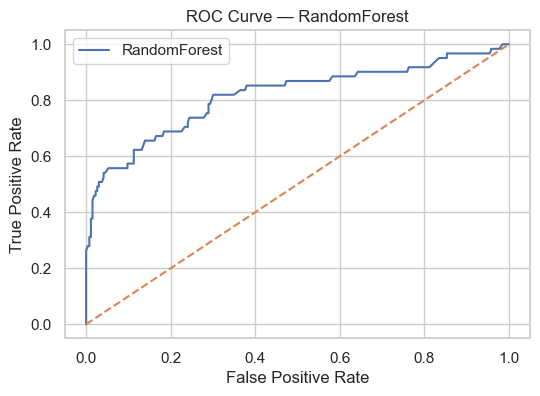

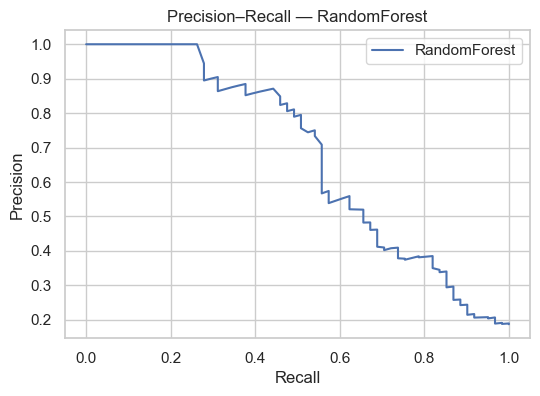

In [62]:
#Evaluation Metrices + ROC/PR Curves
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy":  float((y_pred == y_test).mean()),
    "Precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "Recall":    float(recall_score(y_test, y_pred, zero_division=0)),
    "F1":        float(f1_score(y_test, y_pred, zero_division=0)),
    "AUC_ROC":   float(roc_auc_score(y_test, y_proba))
}
print("=== Test Metrics ===")
for k,v in metrics.items():
    print(f"{k:>10}: {v:.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="RandomForest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — RandomForest"); plt.legend(); plt.show()

# Precision–Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(rec, prec, label="RandomForest")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall — RandomForest"); plt.legend(); plt.show()


,feature,importance
0,DurationDays,0.202479
1,StartDOY,0.141762
2,StartWeekday,0.070726
3,ArchiveYear,0.052129
4,StartYear,0.051437
5,StartMonth,0.044605
6,PersonnelInvolved,0.040048
7,Engines,0.027417
8,CrewsInvolved,0.017677
9,CountyPrimary_Riverside,0.016361


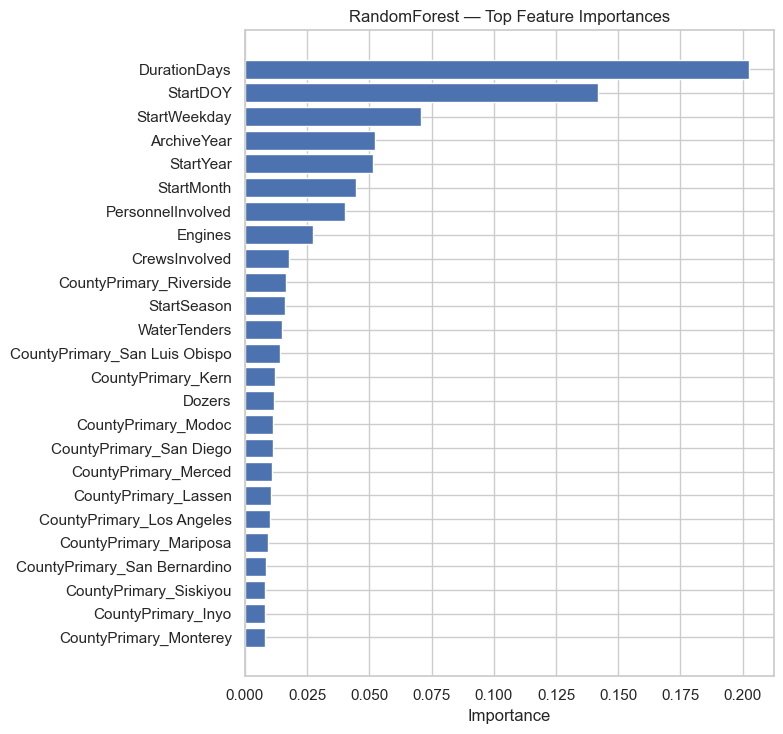

Saved: /Users/gopikrishnareddykatkuri/rf_feature_importances.csv


In [63]:
# Extract OHE feature names + numeric names in the correct order
ohe_step = pipe.named_steps["pre"].named_transformers_["cat"].named_steps["ohe"]
try:
    cat_names = list(ohe_step.get_feature_names_out(candidate_categorical))
except Exception:
    # older sklearn fallback
    cat_names = list(ohe_step.get_feature_names(candidate_categorical))

num_names = candidate_numeric
feature_names = cat_names + num_names

importances = pipe.named_steps["rf"].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

TOP_N = 25
fi_top = fi.head(TOP_N).reset_index().rename(columns={"index":"feature", 0:"importance"})
display(fi_top)

plt.figure(figsize=(8, max(4, 0.3*len(fi_top))))
plt.barh(list(reversed(fi_top["feature"])), list(reversed(fi_top["importance"])))
plt.xlabel("Importance"); plt.title("RandomForest — Top Feature Importances")
plt.tight_layout(); plt.show()

# Save to disk
fi_path = "rf_feature_importances.csv"
pd.DataFrame(fi_top).to_csv(fi_path, index=False)
print("Saved:", os.path.abspath(fi_path))


In [64]:
nl_numeric = [c for c in ["ArchiveYear","StartYear","StartMonth","StartDOY","StartWeekday","StartSeason"] if c in fe.columns]
nl_categorical = [c for c in ["CountyPrimary","Status"] if c in fe.columns]  # you may drop Status if it's not known ex-ante

X2 = fe[nl_numeric + nl_categorical].copy()
y2 = fe[target_col].astype(int)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=RANDOM_STATE
)

# Build a lighter preprocessor for the reduced set
try:
    ohe2 = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe2 = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre2 = ColumnTransformer([
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("ohe", ohe2)]), nl_categorical),
    ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), nl_numeric)
])

rf2 = RandomForestClassifier(
    n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1,
    class_weight="balanced_subsample"
)
pipe2 = Pipeline([("pre", pre2), ("rf", rf2)]).fit(X2_train, y2_train)

y2_pred  = pipe2.predict(X2_test)
y2_proba = pipe2.predict_proba(X2_test)[:, 1]

metrics_nl = {
    "Accuracy":  float((y2_pred == y2_test).mean()),
    "Precision": float(precision_score(y2_test, y2_pred, zero_division=0)),
    "Recall":    float(recall_score(y2_test, y2_pred, zero_division=0)),
    "F1":        float(f1_score(y2_test, y2_pred, zero_division=0)),
    "AUC_ROC":   float(roc_auc_score(y2_test, y2_proba))
}
print("=== No-Leakage Metrics ===")
for k,v in metrics_nl.items():
    print(f"{k:>10}: {v:.4f}")


=== No-Leakage Metrics ===
  Accuracy: 0.8226
 Precision: 0.5714
    Recall: 0.1967
        F1: 0.2927
   AUC_ROC: 0.6410


In [65]:
report = []
report.append("# Random Forest Report — California Fire Incidents\n")
report.append("## Data\n")
report.append(f"- File: `{pd}`\n")
report.append(f"- Rows: {df.shape[0]:,} → Used: {len(work):,}\n")
report.append(f"- Target: `LargeFire = (AcresBurned ≥ 1000)`; Positive rate: {work['LargeFire'].mean():.1%}\n")

report.append("## Features\n")
report.append(f"- Numeric: {', '.join(candidate_numeric)}\n")
report.append(f"- Categorical: {', '.join(candidate_categorical)}\n")
report.append("- Note: `DurationDays`, `PersonnelInvolved`, `PercentContained` may be post-hoc (leakage).\n")

report.append("## Test Metrics — All Features\n")
for k in ["Accuracy","Precision","Recall","F1","AUC_ROC"]:
    report.append(f"- {k}: {metrics[k]:.4f}\n")

report.append("\n**Top features (by importance):**\n")
for i, row in enumerate(fi.head(10).items(), start=1):
    report.append(f"{i:2d}. {row[0]} — {row[1]:.4f}\n")

report.append("\n## Test Metrics — No-Leakage Variant\n")
for k in ["Accuracy","Precision","Recall","F1","AUC_ROC"]:
    report.append(f"- {k}: {metrics_nl[k]:.4f}\n")

report.append("\n## Next steps\n")
report.append("- Add ex-ante predictors: weather (temp/humidity/wind), drought index, vegetation/WUI.\n")
report.append("- Hyperparameter tuning (max_depth, min_samples_leaf, max_features) + k-fold CV.\n")
report.append("- Threshold tuning for desired precision/recall trade-off.\n")

REPORT_PATH = "rf_report.md"
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("".join(report))

print("Saved report to:", os.path.abspath(REPORT_PATH))


Saved report to: /Users/gopikrishnareddykatkuri/rf_report.md
